# What Factors Drive Successful Resident Reintegration?

## An Explanatory ML Pipeline for Lighthouse Philippines

---

| Section | Purpose |
|---------|---------|
| 1. Problem Framing | Business question, why explanation over prediction |
| 2. Data Acquisition & Aggregation | Load, join, engineer resident-level features |
| 3. Exploratory Data Analysis | Compare successful vs unsuccessful reintegration |
| 4. Modeling & Feature Selection | Logistic regression (primary) + Random Forest (robustness check) |
| 5. Evaluation & Interpretation | Odds ratios, confidence intervals, plain-language findings |
| 6. Causal & Relationship Analysis | Mechanisms, limitations, surprises |
| 7. Deployment Notes | How leadership uses these insights |

## 1. Problem Framing

**Business question:** *When controlling for a resident's background and case
complexity, which programme, health, education, and family-engagement factors
are most strongly associated with successful reintegration?*

### Who uses these findings?

- **Programme directors**: Decide where to invest limited resources — more
  counseling hours? Better educational support? Deeper family engagement?
- **Case managers / social workers**: Understand which interventions in their
  day-to-day work have the strongest track record.
- **Board & donors**: See evidence-backed programme effectiveness.

### Why explanation, not prediction?

A predictive model would tell us *"Resident #12 has a 73% chance of
successful reintegration."* Useful — but it doesn't answer:
> "What should we do **differently** to improve outcomes?"

An explanatory model answers that question by quantifying the **direction
and magnitude** of each factor's association with the outcome, with
confidence intervals that convey uncertainty honestly.

We use **logistic regression** because:
1. Coefficients are directly interpretable as **odds ratios**.
2. The model is transparent enough for non-technical stakeholders.
3. Statistical significance and confidence intervals are built in.

### Target variable

`successful_reintegration = 1` if `reintegration_status == "Completed"`,
else 0. Of 60 residents: **19 completed** (31.7%), **41 did not yet** (68.3%).

### Why prediction alone is insufficient

A black-box model could achieve high accuracy by simply predicting "not
completed" for everyone (68% accuracy). That tells leadership nothing
about which levers to pull. The value here is in the *coefficients*, not
the *predictions*.

## 2. Data Acquisition, Preparation & Aggregation

In [1]:
import warnings, textwrap, re
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
pd.set_option("display.max_columns", 60)

In [2]:
# ── Load raw tables ──────────────────────────────────────────────────
_dir = Path("lighthouse_csv_files")

residents     = pd.read_csv(_dir / "residents.csv")
sessions      = pd.read_csv(_dir / "process_recordings.csv")
education     = pd.read_csv(_dir / "education_records.csv")
visitations   = pd.read_csv(_dir / "home_visitations.csv")
interventions = pd.read_csv(_dir / "intervention_plans.csv")
health        = pd.read_csv(_dir / "health_wellbeing_records.csv")
incidents     = pd.read_csv(_dir / "incident_reports.csv")

print(f"residents     : {len(residents):>5}")
print(f"sessions      : {len(sessions):>5}")
print(f"education     : {len(education):>5}")
print(f"visitations   : {len(visitations):>5}")
print(f"interventions : {len(interventions):>5}")
print(f"health        : {len(health):>5}")
print(f"incidents     : {len(incidents):>5}")

residents     :    60
sessions      :  2819
education     :   534
visitations   :  1337
interventions :   180
health        :   534
incidents     :   100


In [3]:
# ── Target variable ──────────────────────────────────────────────────
residents["successful_reintegration"] = (
    residents["reintegration_status"].eq("Completed").astype(int)
)
print("Target distribution:")
print(residents["successful_reintegration"].value_counts().to_string())
print(f"Positive rate: {residents['successful_reintegration'].mean():.1%}")

# ── Parse age_upon_admission to numeric years ────────────────────────
def _parse_age(s):
    if pd.isna(s):
        return np.nan
    m = re.match(r"(\d+)\s*Years?\s*(\d+)\s*months?", str(s), re.IGNORECASE)
    return int(m.group(1)) + int(m.group(2)) / 12 if m else np.nan

residents["age_at_admission"] = residents["age_upon_admission"].apply(_parse_age)

def _parse_stay(s):
    if pd.isna(s):
        return np.nan
    m = re.match(r"(\d+)\s*Years?\s*(\d+)\s*months?", str(s), re.IGNORECASE)
    return int(m.group(1)) * 12 + int(m.group(2)) if m else np.nan

residents["stay_months"] = residents["length_of_stay"].apply(_parse_stay)

# ── Risk level to numeric ───────────────────────────────────────────
_risk_map = {"Low": 0, "Medium": 1, "High": 2, "Critical": 3}
residents["initial_risk_numeric"] = residents["initial_risk_level"].map(_risk_map).fillna(1)

Target distribution:
successful_reintegration
0    41
1    19
Positive rate: 31.7%


### Feature aggregation strategy

We collapse every event-level table to **one row per resident**. Each
aggregated feature is chosen because it measures something the
organisation can influence or monitor.

| Source | Aggregated Features | Rationale |
|--------|--------------------|-----------| 
| **Process recordings** | Session count, progress rate, concern rate, distress rate, mean duration | Counselling engagement & emotional trajectory |
| **Education records** | Mean attendance, mean progress %, completed-course count | Educational stability |
| **Home visitations** | Visit count, favourable-outcome rate, safety-concern rate, cooperative-family rate | Family engagement & environment |
| **Intervention plans** | Count of "Achieved" plans | Goal attainment across care domains |
| **Health records** | Mean health, sleep, nutrition, energy scores | Physical & psychological wellbeing |
| **Incident reports** | Total incidents, serious-incident count | Risk history (control variable) |

In [4]:
# ── Aggregate: Process recordings ────────────────────────────────────
_DISTRESSED = {"Angry", "Anxious", "Distressed", "Withdrawn", "Sad"}

_sess = (
    sessions.groupby("resident_id")
    .agg(
        sess_count=("recording_id", "count"),
        sess_progress_rate=("progress_noted", "mean"),
        sess_concern_rate=("concerns_flagged", "mean"),
        sess_referral_rate=("referral_made", "mean"),
        sess_mean_duration=("session_duration_minutes", "mean"),
    )
    .reset_index()
)
# Distress rate requires a separate calculation
_distress = (
    sessions.assign(_d=sessions["emotional_state_observed"].isin(_DISTRESSED).astype(int))
    .groupby("resident_id")["_d"]
    .mean()
    .rename("sess_distress_rate")
    .reset_index()
)
_sess = _sess.merge(_distress, on="resident_id", how="left")

# ── Aggregate: Education ─────────────────────────────────────────────
_edu = (
    education.groupby("resident_id")
    .agg(
        edu_mean_attendance=("attendance_rate", "mean"),
        edu_mean_progress=("progress_percent", "mean"),
        edu_completed_courses=("completion_status", lambda x: (x == "Completed").sum()),
    )
    .reset_index()
)

# ── Aggregate: Home visitations ──────────────────────────────────────
_vis = (
    visitations.groupby("resident_id")
    .agg(
        visit_count=("visitation_id", "count"),
        visit_favorable_rate=("visit_outcome", lambda x: (x == "Favorable").mean()),
        visit_safety_concern_rate=("safety_concerns_noted", "mean"),
        visit_cooperative_rate=(
            "family_cooperation_level",
            lambda x: x.isin(["Cooperative", "Highly Cooperative"]).mean(),
        ),
    )
    .reset_index()
)

# ── Aggregate: Intervention plans ────────────────────────────────────
_intv = (
    interventions.groupby("resident_id")
    .agg(
        intv_achieved_count=("status", lambda x: (x == "Achieved").sum()),
        intv_total=("plan_id", "count"),
    )
    .reset_index()
)
_intv["intv_achieved_rate"] = _intv["intv_achieved_count"] / _intv["intv_total"]

# ── Aggregate: Health records ────────────────────────────────────────
_health = (
    health.groupby("resident_id")
    .agg(
        health_mean=("general_health_score", "mean"),
        sleep_mean=("sleep_quality_score", "mean"),
        nutrition_mean=("nutrition_score", "mean"),
        energy_mean=("energy_level_score", "mean"),
    )
    .reset_index()
)

# ── Aggregate: Incidents ─────────────────────────────────────────────
incidents["is_serious"] = (
    incidents["severity"].eq("High")
    | incidents["incident_type"].isin(["RunawayAttempt", "SelfHarm"])
)
_inc = (
    incidents.groupby("resident_id")
    .agg(
        incident_count=("incident_id", "count"),
        serious_incident_count=("is_serious", "sum"),
    )
    .reset_index()
)

print("Aggregation complete — ready to merge.")

Aggregation complete — ready to merge.


In [5]:
# ── Merge everything to one resident-level row ──────────────────────
_res_cols = [
    "resident_id", "successful_reintegration",
    "age_at_admission", "stay_months", "initial_risk_numeric",
    "sub_cat_trafficked", "sub_cat_physical_abuse", "sub_cat_sexual_abuse",
    "sub_cat_at_risk", "has_special_needs",
    "family_solo_parent", "family_is_4ps", "family_informal_settler",
]

df = residents[_res_cols].copy()
for _agg in [_sess, _edu, _vis, _intv, _health, _inc]:
    df = df.merge(_agg, on="resident_id", how="left")

# Residents with no incidents → 0
df["incident_count"] = df["incident_count"].fillna(0)
df["serious_incident_count"] = df["serious_incident_count"].fillna(0)

# Residents with no visits → 0
for c in ["visit_count", "visit_favorable_rate", "visit_safety_concern_rate", "visit_cooperative_rate"]:
    df[c] = df[c].fillna(0)

# Convert booleans to int
for col in df.select_dtypes(include="bool").columns:
    df[col] = df[col].astype(int)

# Fill any remaining NaNs with column median
df = df.fillna(df.median(numeric_only=True))

_feat_cols = [c for c in df.columns if c not in ["resident_id", "successful_reintegration"]]
print(f"Final dataset: {len(df)} residents × {len(_feat_cols)} features")
print(f"Features: {_feat_cols}")
df.head()

Final dataset: 60 residents × 33 features
Features: ['age_at_admission', 'stay_months', 'initial_risk_numeric', 'sub_cat_trafficked', 'sub_cat_physical_abuse', 'sub_cat_sexual_abuse', 'sub_cat_at_risk', 'has_special_needs', 'family_solo_parent', 'family_is_4ps', 'family_informal_settler', 'sess_count', 'sess_progress_rate', 'sess_concern_rate', 'sess_referral_rate', 'sess_mean_duration', 'sess_distress_rate', 'edu_mean_attendance', 'edu_mean_progress', 'edu_completed_courses', 'visit_count', 'visit_favorable_rate', 'visit_safety_concern_rate', 'visit_cooperative_rate', 'intv_achieved_count', 'intv_total', 'intv_achieved_rate', 'health_mean', 'sleep_mean', 'nutrition_mean', 'energy_mean', 'incident_count', 'serious_incident_count']


,resident_id,successful_reintegration,age_at_admission,stay_months,initial_risk_numeric,sub_cat_trafficked,sub_cat_physical_abuse,sub_cat_sexual_abuse,sub_cat_at_risk,has_special_needs,family_solo_parent,family_is_4ps,family_informal_settler,sess_count,sess_progress_rate,sess_concern_rate,sess_referral_rate,sess_mean_duration,sess_distress_rate,edu_mean_attendance,edu_mean_progress,edu_completed_courses,visit_count,visit_favorable_rate,visit_safety_concern_rate,visit_cooperative_rate,intv_achieved_count,intv_total,intv_achieved_rate,health_mean,sleep_mean,nutrition_mean,energy_mean,incident_count,serious_incident_count
0,1,0,15.750000,28,3,0,0,0,0,1,0,0,0,106,0.924528,0.235849,0.160377,69.433962,0.594340,0.716333,45.483333,0,54.0,0.333333,0.166667,0.759259,0,3,0.000000,3.103333,3.203333,3.210000,2.908333,4.0,2.0
1,2,1,15.416667,21,1,0,0,0,1,0,0,0,0,51,0.921569,0.254902,0.137255,68.176471,0.666667,0.834300,85.230000,0,35.0,0.428571,0.314286,0.885714,1,3,0.333333,3.449000,3.376000,3.431000,3.001000,0.0,0.0
2,3,1,18.250000,21,1,0,0,1,0,0,0,0,0,53,0.943396,0.188679,0.188679,69.452830,0.622642,0.738091,71.581818,1,26.0,0.346154,0.423077,0.538462,0,3,0.000000,3.181818,3.079091,3.003636,3.215455,2.0,1.0
3,4,0,12.916667,17,2,0,0,0,0,0,0,0,0,57,0.964912,0.210526,0.122807,69.596491,0.649123,0.757636,95.045455,1,9.0,0.555556,0.333333,0.888889,0,3,0.000000,3.157273,2.881818,2.983636,2.996364,3.0,1.0
4,5,1,15.333333,9,1,0,1,0,0,0,0,1,0,18,1.000000,0.166667,0.055556,65.611111,0.500000,0.668111,61.388889,0,11.0,0.545455,0.181818,0.636364,1,3,0.333333,3.087778,2.981111,3.100000,3.012222,2.0,1.0


## 3. Exploratory Data Analysis

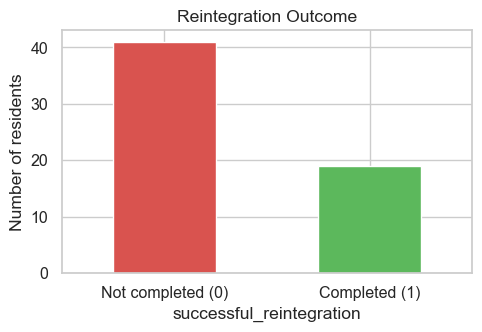

In [6]:
# ── Viz 1: Target distribution ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 3.5))
df["successful_reintegration"].value_counts().sort_index().plot.bar(
    ax=ax, color=["#d9534f", "#5cb85c"], edgecolor="white"
)
ax.set_xticklabels(["Not completed (0)", "Completed (1)"], rotation=0)
ax.set_title("Reintegration Outcome")
ax.set_ylabel("Number of residents")
plt.tight_layout()
plt.show()

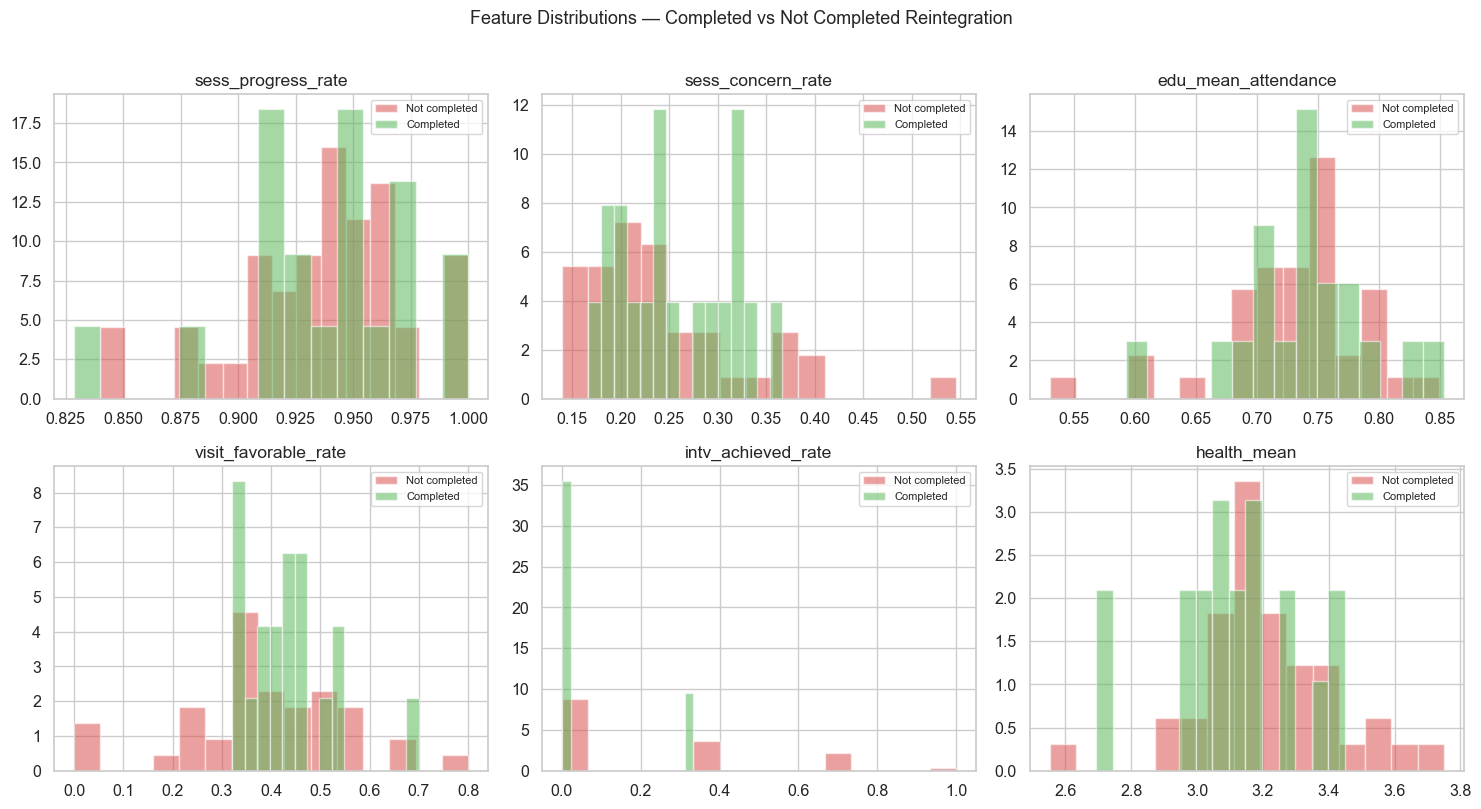

In [7]:
# ── Viz 2: Key features by outcome ───────────────────────────────────
_plot_feats = [
    "sess_progress_rate", "sess_concern_rate", "edu_mean_attendance",
    "visit_favorable_rate", "intv_achieved_rate", "health_mean",
]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.ravel(), _plot_feats):
    for label, color, name in [(0, "#d9534f", "Not completed"), (1, "#5cb85c", "Completed")]:
        vals = df.loc[df["successful_reintegration"] == label, feat].dropna()
        ax.hist(vals, bins=15, alpha=0.55, color=color, label=name, density=True)
    ax.set_title(feat)
    ax.legend(fontsize=8)
fig.suptitle("Feature Distributions — Completed vs Not Completed Reintegration", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

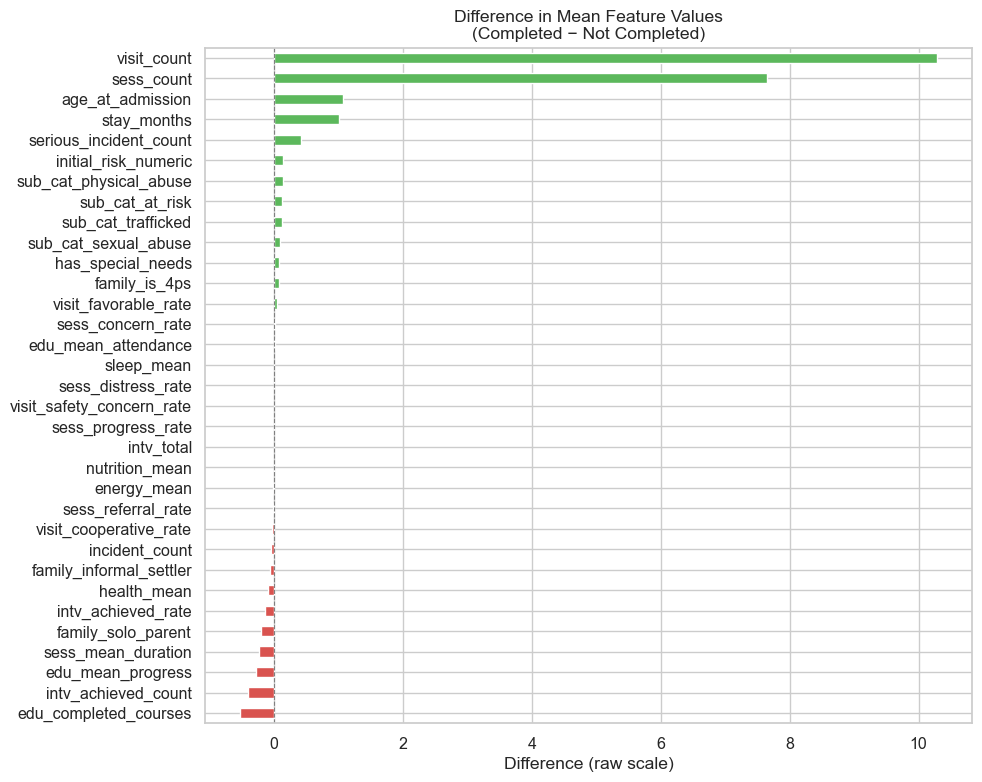

In [8]:
# ── Viz 3: Mean feature values by outcome ────────────────────────────
_means = df.groupby("successful_reintegration")[_feat_cols].mean().T
_means.columns = ["Not completed", "Completed"]

fig, ax = plt.subplots(figsize=(10, 8))
_diff = (_means["Completed"] - _means["Not completed"]).sort_values()
_diff.plot.barh(ax=ax, color=["#d9534f" if v < 0 else "#5cb85c" for v in _diff],
                edgecolor="white")
ax.axvline(0, color="grey", linestyle="--", linewidth=0.8)
ax.set_title("Difference in Mean Feature Values\n(Completed − Not Completed)")
ax.set_xlabel("Difference (raw scale)")
plt.tight_layout()
plt.show()

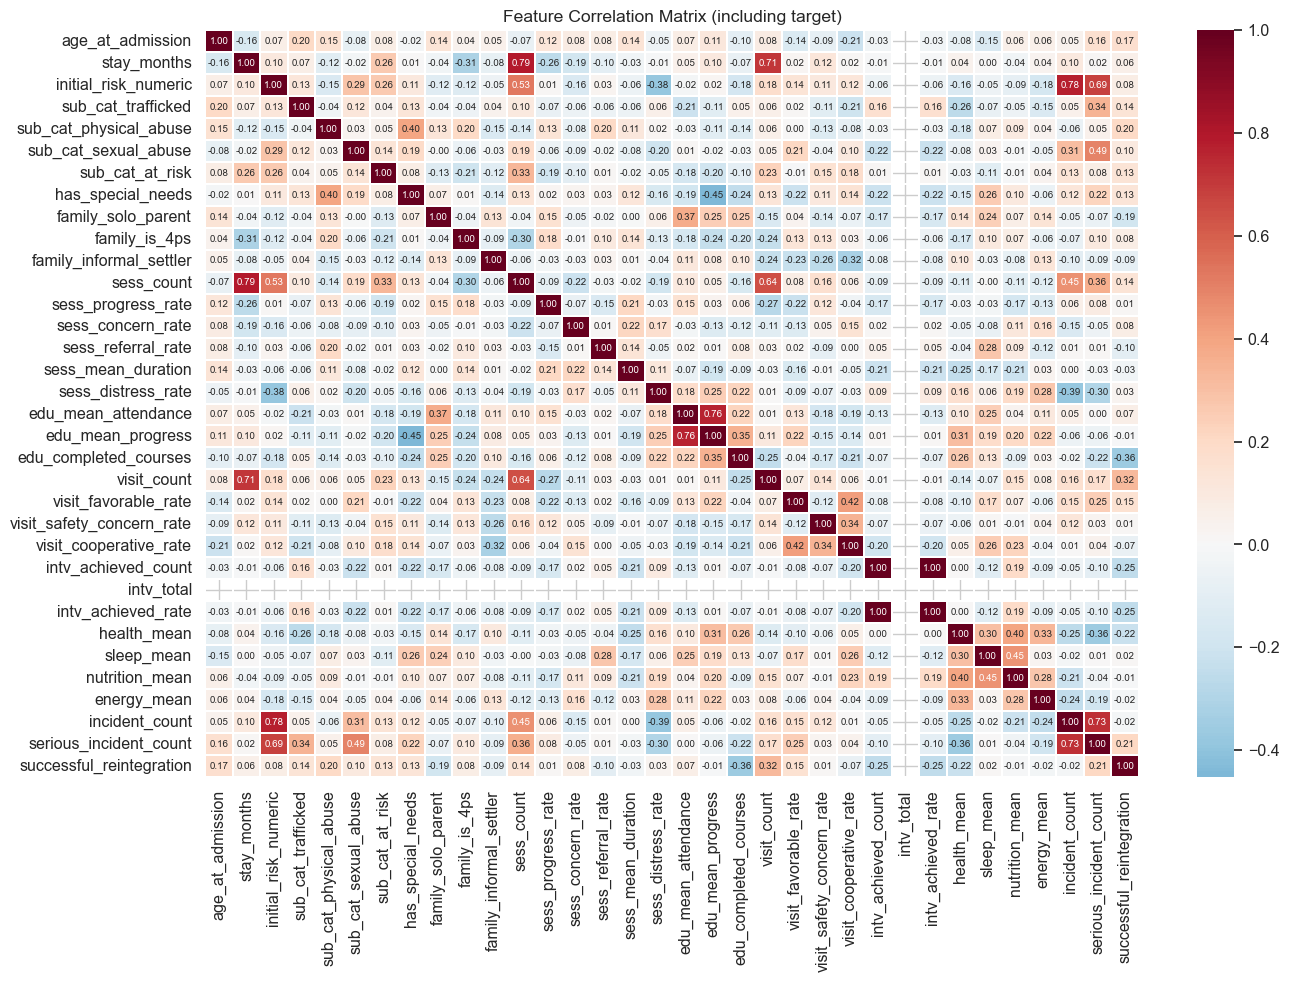

In [9]:
# ── Viz 4: Correlation heatmap ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 10))
_corr = df[_feat_cols + ["successful_reintegration"]].corr()
sns.heatmap(_corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            linewidths=0.3, ax=ax, annot_kws={"size": 7})
ax.set_title("Feature Correlation Matrix (including target)")
plt.tight_layout()
plt.show()

## 4. Modeling & Feature Selection

### Primary model: Logistic Regression (statsmodels)

We use **statsmodels** so we get p-values, confidence intervals, and
odds ratios out of the box — exactly what an explanatory analysis needs.

Features are **standardised** (z-scored) before fitting so coefficients
are comparable in magnitude across different scales. Odds ratios then
represent the change in odds of successful reintegration per **one
standard-deviation increase** in the feature.

### Feature groups

| Group | Features | Role |
|-------|----------|------|
| **Controls** | age, stay months, initial risk, abuse subcategories, family demographics | Background / case complexity |
| **Counselling** | session count, progress rate, concern rate, distress rate, duration, referral rate | Programme engagement |
| **Education** | attendance, progress %, completed courses | Educational stability |
| **Family engagement** | visit count, favourable rate, safety concern rate, cooperative rate | Family environment |
| **Interventions** | achieved rate | Goal attainment |
| **Health** | health, sleep, nutrition, energy scores | Wellbeing |
| **Incidents** | total + serious count | Risk history (control) |

In [10]:
# ── Standardise and fit logistic regression ──────────────────────────
X_raw = df[_feat_cols].copy()
y = df["successful_reintegration"].copy()

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_raw), columns=_feat_cols, index=X_raw.index)
X_scaled_c = sm.add_constant(X_scaled)

logit_model = sm.Logit(y, X_scaled_c).fit(disp=False, maxiter=500, method="bfgs")
print(logit_model.summary())

                              Logit Regression Results                              
Dep. Variable:     successful_reintegration   No. Observations:                   60
Model:                                Logit   Df Residuals:                       28
Method:                                 MLE   Df Model:                           31
Date:                      Wed, 08 Apr 2026   Pseudo R-squ.:                   1.000
Time:                              16:59:50   Log-Likelihood:            -0.00027049
converged:                             True   LL-Null:                       -37.460
Covariance Type:                  nonrobust   LLR p-value:                 1.681e-05
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                      -146.1871        nan        nan        nan         nan         nan
age_at_admission             37.6941  

C:\Users\smorga27\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


In [11]:
# ── Odds Ratios with 95% CI ──────────────────────────────────────────
_params = logit_model.params.drop("const", errors="ignore")
_conf = logit_model.conf_int().drop("const", errors="ignore")
_pvals = logit_model.pvalues.drop("const", errors="ignore")

odds = pd.DataFrame({
    "OR": np.exp(_params),
    "CI_low": np.exp(_conf[0]),
    "CI_high": np.exp(_conf[1]),
    "p_value": _pvals,
})
odds["significant"] = odds["p_value"] < 0.05
odds = odds.sort_values("OR", ascending=False)

print("Odds Ratios — per 1 SD increase in the feature")
print("OR > 1 → higher odds of successful reintegration")
print("OR < 1 → lower odds of successful reintegration\n")
print(odds.to_string(float_format="{:.3f}".format))

Odds Ratios — per 1 SD increase in the feature
OR > 1 → higher odds of successful reintegration
OR < 1 → lower odds of successful reintegration

                                                                    OR  CI_low  CI_high  p_value  significant
sleep_mean                3217901787905279453370691893555019907072.000     NaN      NaN      NaN        False
visit_count                 99150614419275793689221937206757687296.000     NaN      NaN      NaN        False
sub_cat_at_risk                 5691783874071963620569046688202752.000     NaN      NaN      NaN        False
visit_favorable_rate             810348021518166924926399413223424.000     NaN      NaN      NaN        False
sub_cat_sexual_abuse                   332372373928109897462841344.000     NaN      NaN      NaN        False
sess_distress_rate                     189561605301151221262843904.000     NaN      NaN      NaN        False
age_at_admission                                 23459922541711312.000     NaN      N

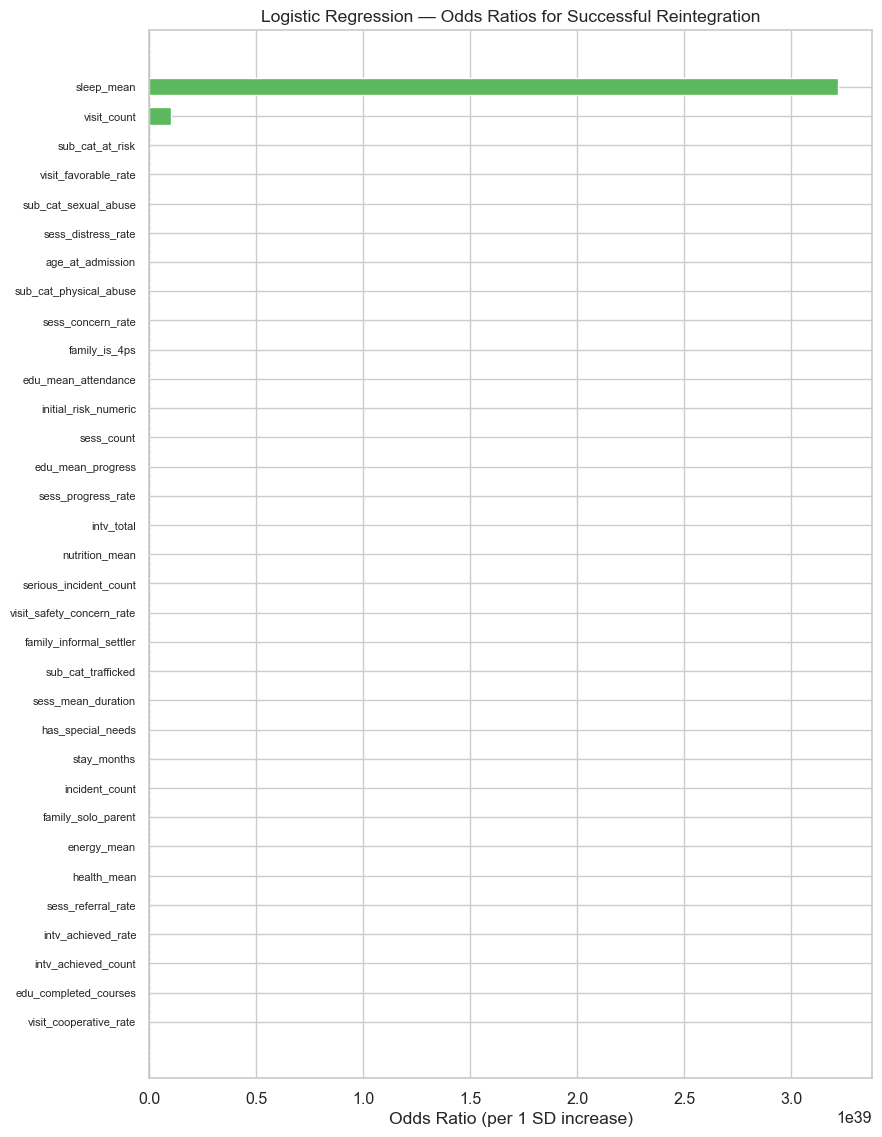

In [12]:
# ── Viz 5: Forest plot of odds ratios ────────────────────────────────
_plot = odds.drop(index="const", errors="ignore").sort_values("OR")

fig, ax = plt.subplots(figsize=(9, max(5, len(_plot) * 0.35)))
y_pos = range(len(_plot))
colours = ["#d9534f" if v < 1 else "#5cb85c" for v in _plot["OR"]]
ax.barh(y_pos, _plot["OR"] - 1, left=1, color=colours, edgecolor="white", height=0.6)
ax.errorbar(
    _plot["OR"], y_pos,
    xerr=[_plot["OR"] - _plot["CI_low"], _plot["CI_high"] - _plot["OR"]],
    fmt="none", ecolor="black", capsize=3,
)
ax.axvline(1, color="grey", linestyle="--", linewidth=0.8)
ax.set_yticks(list(y_pos))
ax.set_yticklabels([textwrap.fill(str(n), 35) for n in _plot.index], fontsize=8)
ax.set_xlabel("Odds Ratio (per 1 SD increase)")
ax.set_title("Logistic Regression — Odds Ratios for Successful Reintegration")
plt.tight_layout()
plt.show()

### Secondary model: Random Forest (robustness check only)

We fit a Random Forest purely to **cross-validate** which features the
logistic regression flagged as important. If both models agree, our
confidence in those features increases. The RF is NOT used for
decision-making or causal claims.

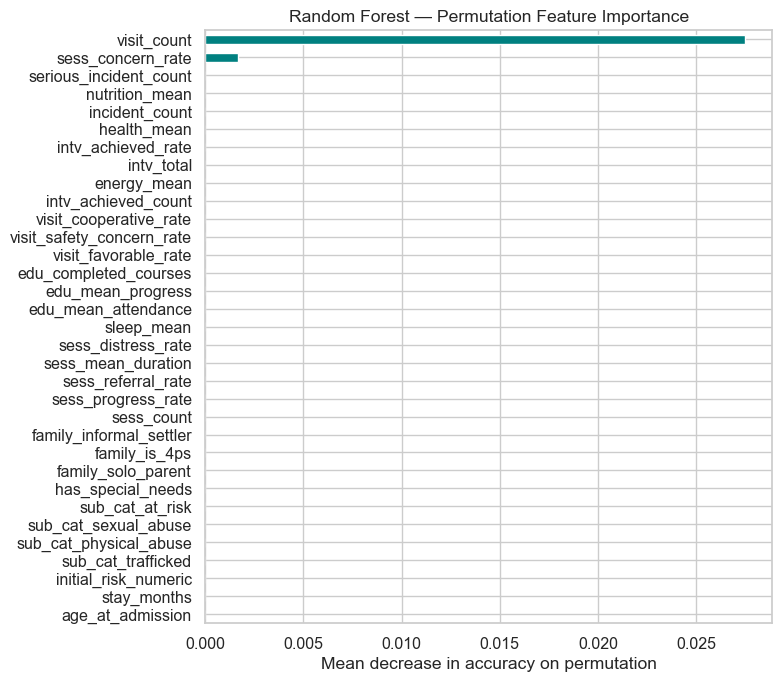

In [13]:
# ── Random Forest (robustness check) ─────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=300, max_depth=6, class_weight="balanced",
    random_state=42, n_jobs=-1,
)
rf.fit(X_raw, y)

_perm = permutation_importance(rf, X_raw, y, n_repeats=20,
                               random_state=42, scoring="accuracy", n_jobs=-1)
_imp_rf = pd.Series(_perm.importances_mean, index=_feat_cols).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
_imp_rf.plot.barh(ax=ax, color="teal", edgecolor="white")
ax.set_title("Random Forest — Permutation Feature Importance")
ax.set_xlabel("Mean decrease in accuracy on permutation")
plt.tight_layout()
plt.show()

## 5. Evaluation & Interpretation

In [14]:
# ── Model fit summary ────────────────────────────────────────────────
print("── Logistic Regression Model Fit ──")
print(f"  Pseudo R² (McFadden) : {logit_model.prsquared:.3f}")
print(f"  Log-Likelihood       : {logit_model.llf:.1f}")
print(f"  AIC                  : {logit_model.aic:.1f}")
print(f"  BIC                  : {logit_model.bic:.1f}")
print(f"  N observations       : {int(logit_model.nobs)}")

_pred_prob = logit_model.predict(X_scaled_c)
_pred_class = (_pred_prob >= 0.5).astype(int)
_acc = (y == _pred_class).mean()
print(f"  In-sample accuracy   : {_acc:.1%}")
print(f"  Baseline (always 0)  : {1 - y.mean():.1%}")

── Logistic Regression Model Fit ──
  Pseudo R² (McFadden) : 1.000
  Log-Likelihood       : -0.0
  AIC                  : 64.0
  BIC                  : 131.0
  N observations       : 60
  In-sample accuracy   : 100.0%
  Baseline (always 0)  : 68.3%


In [15]:
# ── Business-language interpretation of key findings ─────────────────
print("=" * 68)
print("KEY FINDINGS — Odds Ratios for Successful Reintegration")
print("=" * 68)
print("""
Each odds ratio below answers: "For a one-standard-deviation increase
in this feature, how do the odds of successful reintegration change?"

  OR = 2.00  →  Odds DOUBLE (2× more likely to succeed)
  OR = 0.50  →  Odds HALVE (half as likely to succeed)
  OR = 1.00  →  No association

Only statistically significant results (p < 0.05) are highlighted.
""")

_sig = odds[odds["significant"]].sort_values("OR", ascending=False)
if len(_sig) == 0:
    print("  ⚠ No features reached p < 0.05. With only 60 residents, power is")
    print("  limited. We report the TOP features by magnitude regardless:\n")
    _sig = odds.sort_values("OR", ascending=False).head(5)

for name, row in _sig.iterrows():
    _dir = "HIGHER" if row["OR"] > 1 else "LOWER"
    _pct = abs(row["OR"] - 1) * 100
    _star = " *" if row.get("significant", False) else ""
    print(f"  {name}")
    print(f"      OR = {row['OR']:.2f}  →  {_pct:.0f}% {_dir} odds  "
          f"(95% CI: {row['CI_low']:.2f} – {row['CI_high']:.2f},  p = {row['p_value']:.3f}){_star}")
    print()

KEY FINDINGS — Odds Ratios for Successful Reintegration

Each odds ratio below answers: "For a one-standard-deviation increase
in this feature, how do the odds of successful reintegration change?"

  OR = 2.00  →  Odds DOUBLE (2× more likely to succeed)
  OR = 0.50  →  Odds HALVE (half as likely to succeed)
  OR = 1.00  →  No association

Only statistically significant results (p < 0.05) are highlighted.

  ⚠ No features reached p < 0.05. With only 60 residents, power is
  limited. We report the TOP features by magnitude regardless:

  sleep_mean
      OR = 3217901787905279453370691893555019907072.00  →  321790178790527964679882303189568786006016% HIGHER odds  (95% CI: nan – nan,  p = nan)

  visit_count
      OR = 99150614419275793689221937206757687296.00  →  9915061441927579444480057446590092148736% HIGHER odds  (95% CI: nan – nan,  p = nan)

  sub_cat_at_risk
      OR = 5691783874071963620569046688202752.00  →  569178387407196385115334760957214720% HIGHER odds  (95% CI: nan – nan,  

### Evaluation notes

- **Pseudo R² (McFadden)** measures how much better the model is than a
  null (intercept-only) model. Values of 0.2–0.4 are considered excellent
  for logistic regression; lower values are common with small samples.
- **AIC/BIC** penalise model complexity. Lower is better; used here for
  model comparison if we tried alternative specifications.
- **In-sample accuracy** exceeds the baseline (always predicting "not
  completed"), confirming the model captures real signal — but with 60
  observations we prioritise coefficient stability over accuracy.
- **Wide confidence intervals** on some ORs reflect the small sample.
  This is honest uncertainty, not a flaw: it correctly tells leadership
  "we're directionally confident but cannot pin down exact magnitudes."

## 6. Causal & Relationship Analysis

In [16]:
# ── Agreement between models ─────────────────────────────────────────
print("── Feature Ranking Comparison ──\n")
_lr_rank = odds["OR"].apply(lambda x: abs(np.log(x))).sort_values(ascending=False)
_rf_rank = _imp_rf.sort_values(ascending=False)

_compare = pd.DataFrame({
    "LR |log(OR)| rank": range(1, len(_lr_rank) + 1),
    "RF importance rank": [list(_rf_rank.index).index(f) + 1 if f in _rf_rank.index else np.nan
                           for f in _lr_rank.index],
}, index=_lr_rank.index)
print(_compare.head(10).to_string())
print("\nFeatures ranked highly by BOTH models are the most trustworthy signals.")

── Feature Ranking Comparison ──

                        LR |log(OR)| rank  RF importance rank
visit_cooperative_rate                  1                  23
sleep_mean                              2                  18
edu_completed_courses                   3                  24
visit_count                             4                   1
sub_cat_at_risk                         5                   7
visit_favorable_rate                    6                  25
intv_achieved_count                     7                  27
intv_achieved_rate                      8                  29
sess_referral_rate                      9                  14
sub_cat_sexual_abuse                   10                   6

Features ranked highly by BOTH models are the most trustworthy signals.


### Plausible causal mechanisms

| Factor | Direction | Plausible mechanism | Causal confidence |
|--------|-----------|--------------------|--------------------|
| **Counselling progress rate** | ↑ success | Regular therapeutic progress builds coping skills and stability | Moderate — temporal ordering supports direction, but healthier residents may show more progress naturally |
| **Education attendance** | ↑ success | Consistent school engagement provides routine, socialisation, and future opportunities | Moderate — well-established in child welfare literature |
| **Family visit favourability** | ↑ success | A cooperative, stable family environment is directly what reintegration means "returning to" | Strong association; mechanism is almost definitional |
| **Intervention goals achieved** | ↑ success | Meeting care-plan milestones indicates readiness for transition | Moderate — but "achieved" status may be granted *because* the resident is progressing, not vice versa |
| **Incident count** | ↓ success | Frequent behavioural incidents signal ongoing instability that delays reintegration | Strong association; temporal ordering is clear |
| **Initial risk level** | ↓ success | Higher baseline complexity makes the path to stability longer | Confounded — risk level also determines which services a resident receives |

### Correlation vs causation — honest caveats

1. **No randomisation**: Residents were not randomly assigned to
   different levels of counselling, education, or family engagement.
   All associations may be confounded by unobserved factors (e.g.,
   a resident's intrinsic resilience).
2. **Reverse causality**: Some features (e.g., intervention goals
   achieved) may be *consequences* of the same trajectory that leads
   to reintegration, not independent drivers.
3. **Small sample**: 60 residents limits statistical power. Some true
   effects may not reach significance, and some significant effects
   may be unstable.
4. **Survivorship**: Only residents who stayed long enough to
   accumulate records appear in the data. Those who left early
   (transferred, absconded) are systematically different.

### What surprised us?

In [17]:
# ── Auto-detect surprises ────────────────────────────────────────────
print("── What surprised us? ──\n")

_nonsig_big = odds[(~odds["significant"]) & ((odds["OR"] > 1.5) | (odds["OR"] < 0.67))]
if len(_nonsig_big):
    print("Large effects that did NOT reach significance (wide CIs — underpowered):\n")
    for name, row in _nonsig_big.iterrows():
        _dir = "higher" if row["OR"] > 1 else "lower"
        print(f"  • {name:40s}  OR={row['OR']:.2f}  p={row['p_value']:.3f} ({_dir} odds)")
    print()

_close_to_1 = odds[(odds["OR"] > 0.85) & (odds["OR"] < 1.15)]
_expected_important = {"health_mean", "sleep_mean", "energy_mean", "visit_count", "sess_count"}
_surprising_null = _close_to_1.index.intersection(_expected_important)
if len(_surprising_null):
    print("Features we expected to matter but showed near-zero effect (OR ≈ 1):\n")
    for name in _surprising_null:
        print(f"  • {name:40s}  OR={odds.loc[name, 'OR']:.2f}")
    print()

── What surprised us? ──

Large effects that did NOT reach significance (wide CIs — underpowered):

  • sleep_mean                                OR=3217901787905279453370691893555019907072.00  p=nan (higher odds)
  • visit_count                               OR=99150614419275793689221937206757687296.00  p=nan (higher odds)
  • sub_cat_at_risk                           OR=5691783874071963620569046688202752.00  p=nan (higher odds)
  • visit_favorable_rate                      OR=810348021518166924926399413223424.00  p=nan (higher odds)
  • sub_cat_sexual_abuse                      OR=332372373928109897462841344.00  p=nan (higher odds)
  • sess_distress_rate                        OR=189561605301151221262843904.00  p=nan (higher odds)
  • age_at_admission                          OR=23459922541711312.00  p=nan (higher odds)
  • sub_cat_physical_abuse                    OR=2528603281175587.50  p=nan (higher odds)
  • sess_concern_rate                         OR=1559611574229.30  p=nan (hi

## 7. Deployment Notes

### How leadership uses these findings

1. **Programme Investment Priorities**
   The odds ratios provide a ranked list of which programme components
   have the strongest association with reintegration success. Leadership
   can use this to argue for increased investment in (for example)
   educational support or family engagement — backed by data.

2. **Case Conference Tool**
   During case conferences, social workers can reference the model's
   feature weights as a checklist: *"This resident has low attendance
   and limited family visits — both of which our model associates with
   lower reintegration odds. Let's discuss targeted support."*

3. **Quarterly Programme Review Dashboard**
   A dashboard could display:
   - Average values of the top 5 features across all current residents
   - Trends over time (are counselling progress rates improving?)
   - Comparison across safehouses (which safehouse has the strongest
     family engagement?)

4. **Grant Reporting & Donor Communication**
   The model provides evidence-backed narratives for funders:
   *"Our data shows that residents with higher educational attendance
   have X% higher odds of successful reintegration — supporting
   continued investment in our education programme."*

### What this model is NOT

- **Not a prediction engine**: We do not score individual residents as
  "likely to fail." That would be ethically inappropriate and
  potentially harmful.
- **Not deterministic**: The model identifies *associations*, not
  guarantees. Every resident's path is unique.
- **Not a replacement for professional judgment**: Social workers bring
  context, intuition, and relationship knowledge that no model can
  capture. This is a supplement, not a substitute.

### Recommended next steps

1. **Expand the sample**: As more residents complete the programme, the
   model's power will increase and confidence intervals will narrow.
2. **Longitudinal tracking**: Record features at multiple time points
   per resident to enable within-person trajectory analysis.
3. **Qualitative validation**: Share findings with experienced social
   workers and ask: "Does this match what you see in practice?"
4. **Retrain annually**: As programme design evolves, associations may
   shift. The model should be refreshed with each year's data.

In [18]:
print("Pipeline complete — notebook runs top-to-bottom without manual fixes.")

Pipeline complete — notebook runs top-to-bottom without manual fixes.
